# Outlier Patch Detection on TR1 Data

Applies the per-patch amplitude perturbation analysis from `outlier_patch_test.ipynb`
to the first TR1 shear map (`SHE-1`).  The 48-patch tile mask serves as both the
patch decomposition and the jackknife regions.

In [73]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

import heracles
import heracles.healpy
import heracles.dices as dices


## 1. Load catalog and build shear maps

We read `23405.fits` with `heracles.FitsCatalog` and select tomographic bin 1.
The shear (SHE) and weight (WHT) maps are produced by `heracles.map_catalogs`
using the LensMC ellipticity columns (`she_lensmc_e1/e2/weight`).

In [74]:
from heracles.core import update_metadata

DATA_DIR          = "tr1_data"
DATA_PRODUCTS_DIR = "data_products"
CAT_FILE  = f"{DATA_DIR}/23405.fits"

nside     = 2048
lmax_data = 4000
lmax_mask = 6000
lmax_out  = 2500
lmin      = 500
nlbins    = 10
methods   = ["lensmc"]  # both shear estimators
bins      = [0] #list(range(7))          # 0 = full catalog, 1-6 = tomo bins

mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask.fits")
mask = hp.ud_grade(mask, nside_out=nside)

catalog  = heracles.FitsCatalog(CAT_FILE)
catalog.visibility = mask
catalogs = {0: catalog[f"tom_bin_id != -1"]}  # full catalog
# Switch off the tomographic binning for now, to increase the S/N of the maps and avoid outliers in the low-z bins
#for i in range(1, 7):
#    catalogs[i] = catalog[f"tom_bin_id == {i}"]

mapper_data = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

# Create data-products directory tree
os.makedirs(DATA_PRODUCTS_DIR, exist_ok=True)
for method in methods:
    os.makedirs(f"{DATA_PRODUCTS_DIR}/{method}", exist_ok=True)

she_maps_all = {}
wht_maps_all = {}

for method in methods:
    cache_file = f"{DATA_PRODUCTS_DIR}/{method}/maps_nside_{nside}.fits"

    if os.path.exists(cache_file):
        maps = heracles.read_maps(cache_file)
        she_maps_all[method] = {k: maps[k] for k in maps if k[0] == "SHE"}
        wht_maps_all[method] = {k: maps[k] for k in maps if k[0] == "WHT"}
        print(f"  Loaded maps [{method}] from cache")
    else:
        fields_she = {
            "SHE": heracles.Shears(
                mapper_data,
                "right_ascension",
                "declination",
                f"she_{method}_e1",
                f"-she_{method}_e2",
                f"she_{method}_weight",
                mask="WHT",
            ),
        }
        fields_wht = {
            "WHT": heracles.Weights(
                mapper_mask,
                "right_ascension",
                "declination",
                f"she_{method}_weight",
            ),
        }
        she_maps_all[method] = heracles.map_catalogs(fields_she, catalogs)
        wht_maps_all[method] = heracles.map_catalogs(fields_wht, catalogs)
        heracles.write_maps(cache_file, {**she_maps_all[method], **wht_maps_all[method]}, clobber=True)
        print(f"  Mapped and cached [{method}]  ({len(bins)} bins)")

print(f"Data-products dir: {DATA_PRODUCTS_DIR}/")


  Loaded maps [lensmc] from cache
Data-products dir: data_products/


## 2. Build the patch segmentation map

We divide the survey footprint into roughly 20-sq-deg patches using
`skysegmentor.segmentmapN` on the WHT weight map.

In [75]:
import skysegmentor

# Per-method, per-bin bias from metadata
b_all = {
    method: {
        ibin: she_maps_all[method][("SHE", ibin)].dtype.metadata["bias"]
        for ibin in bins
    }
    for method in methods
}

# Patch layout is method- and bin-independent
fsky      = mask.sum() / hp.nside2npix(nside)
area_deg2 = fsky * 4 * np.pi * (180 / np.pi) ** 2
n_patches = max(1, round(area_deg2 / 20))
print(f"Survey area: {area_deg2:.1f} sq deg  \u2192  {n_patches} patches of ~{area_deg2/n_patches:.1f} sq deg each")

jkmap = skysegmentor.segmentmapN(mask, n_patches)
print(f"jkmap unique labels: {np.unique(jkmap[jkmap > 0]).astype(int)}")


Survey area: 504.5 sq deg  →  25 patches of ~20.2 sq deg each
jkmap unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


/tmp/ipykernel_74424/1235972990.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c = float(lon_c), float(lat_c)
/tmp/ipykernel_74424/1235972990.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


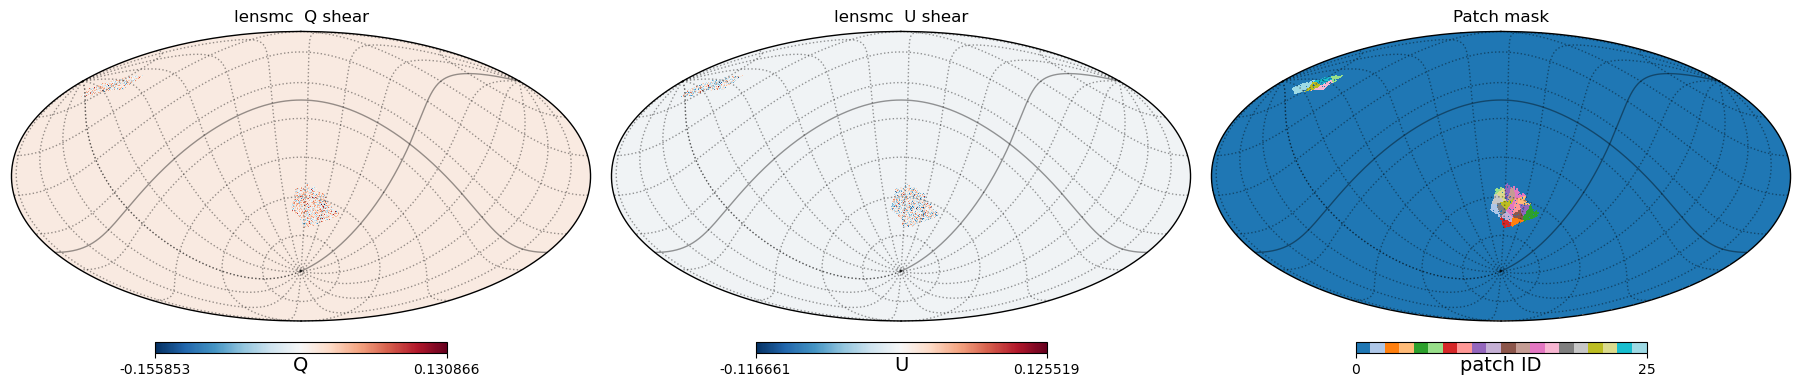

In [76]:
# ── Diagnostic: SHE-1 maps for both methods + patch regions ──
footprint_pix = np.where(she_maps_all["lensmc"][("SHE", 0)][0] != 0)[0]
vec = np.array(hp.pix2vec(nside, footprint_pix))
centre_vec = vec.mean(axis=1)
centre_vec /= np.linalg.norm(centre_vec)
lon_c, lat_c = hp.vec2ang(centre_vec, lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

fig = plt.figure(figsize=(18, 8))

for row, method in enumerate(methods):
    she_m = she_maps_all[method]
    hp.mollview(
        she_m[("SHE", 0)][0], fig=fig, sub=(2, 3, row * 3 + 1),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  Q shear", unit="Q",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        she_m[("SHE", 0)][1], fig=fig, sub=(2, 3, row * 3 + 2),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  U shear", unit="U",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        jkmap, fig=fig, sub=(2, 3, row * 3 + 3),
        rot=(lon_c, lat_c, 0),
        title="Patch mask", unit="patch ID",
        cmap="tab20", notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Heracles setup

In [77]:
# Per-patch and full-footprint naturalspice: SHE @ lmax_data, WHT @ lmax_mask
fields = {
    "SHE": heracles.Shears(mapper_data, mask="WHT"),
    "WHT": heracles.Weights(mapper_data),
}
print(f"Data mapper: nside={mapper_data.nside}, lmax={mapper_data.lmax}")
print(f"Mask mapper: nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

Data mapper: nside=2048, lmax=4000
Mask mapper: nside=2048, lmax=6000


## 4. Per-patch alms and pseudo-$C_\ell$

For each patch we:
1. Mask the shear and weight maps to that patch's pixels
2. Transform to alms
3. Compute the pseudo-$C_\ell$

In [78]:
import heracles.dices as dices

# Nested dict: all_data_cls[method][label][ibin]
# First hierarchy = patch region, second = tomographic bin
all_data_cls = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_mask_cls = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}

for method in methods:
    for label in range(1, n_patches + 1):
        cache_file = f"{DATA_PRODUCTS_DIR}/{method}/pseudo_cls_patch_{label:03d}_lmax{lmax_data}.fits"

        if os.path.exists(cache_file):
            # Load pseudo-Cls from cache (avoids recomputing SHTs)
            combined = heracles.read(cache_file)
            for ibin in bins:
                all_data_cls[method][label][ibin] = {("SHE", "SHE", ibin, ibin): combined[("SHE", "SHE", ibin, ibin)]}
                all_mask_cls[method][label][ibin] = {("WHT", "WHT", ibin, ibin): combined[("WHT", "WHT", ibin, ibin)]}
        else:
            patch_mask = jkmap == label
            combined = {}
            for ibin in bins:
                she = she_maps_all[method][("SHE", ibin)]
                wht = wht_maps_all[method][("WHT", ibin)]
                b   = b_all[method][ibin]

                she_p = she.copy(); she_p[:, ~patch_mask] = 0.0
                wht_p = wht.copy(); wht_p[~patch_mask]    = 0.0
                update_metadata(she_p, fsky=fsky/n_patches, bias=b/n_patches)

                shear_alm = mapper_data.transform(she_p)
                mask_alm  = mapper_mask.transform(wht_p)

                all_data_cls[method][label][ibin] = heracles.angular_power_spectra({("SHE", ibin): shear_alm})
                all_mask_cls[method][label][ibin] = heracles.angular_power_spectra({("WHT", ibin): mask_alm})
                combined.update(all_data_cls[method][label][ibin])
                combined.update(all_mask_cls[method][label][ibin])

            heracles.write(cache_file, combined, clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 5. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [79]:
ell_data = np.arange(0, lmax_data + 1)
ell_out  = np.arange(0, lmax_out + 1)
ledges = np.logspace(np.log10(lmin), np.log10(lmax_out), nlbins + 1)
lgrid = 0.5 * (ledges[:-1] + ledges[1:])

In [80]:
from heracles.unmixing import _naturalspice, logistic
try:
    from copy import replace
except ImportError:
    from dataclasses import replace

rcond     = 0.7
k         = 130.0
rcond_str = f"rcond{rcond:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_corrf          = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_unmixed_binned = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}

print(f"Two-step naturalspice  (rcond={rcond}, k={k}) ...")
for method in methods:
    for label in range(1, n_patches + 1):
        corrf_file = f"{DATA_PRODUCTS_DIR}/{method}/corrf_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"
        cls_file   = f"{DATA_PRODUCTS_DIR}/{method}/decoupled_cls_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"

        if os.path.exists(corrf_file) and os.path.exists(cls_file):
            corrf_data = heracles.read(corrf_file)
            cls_data   = heracles.read(cls_file)
            for ibin in bins:
                key = ("SHE", "SHE", ibin, ibin)
                all_corrf[method][label][ibin]          = corrf_data[key]
                all_unmixed_binned[method][label][ibin] = cls_data[key]
        else:
            corrf_out, cls_out = {}, {}
            for ibin in bins:
                data = all_data_cls[method][label][ibin]
                mask = all_mask_cls[method][label][ibin]
                key  = ("SHE", "SHE", ibin, ibin)

                wd = heracles.cl2corr(heracles.binned(data, np.arange(0, lmax_mask + 2)))
                wm = heracles.cl2corr(mask)
                for m_key in list(wm.keys()):
                    a = wm[m_key].array
                    wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond * a.max()), k=k))

                corrf     = _naturalspice(wd, wm, fields)
                unmixed   = heracles.binned(heracles.corr2cl(corrf), np.arange(0, lmax_out + 1))
                binned_cl = heracles.binned(unmixed, ledges)

                all_corrf[method][label][ibin]          = corrf[key]
                all_unmixed_binned[method][label][ibin] = binned_cl[key]
                corrf_out[key] = corrf[key]
                cls_out[key]   = binned_cl[key]

            heracles.write(corrf_file, corrf_out, clobber=True)
            heracles.write(cls_file,   cls_out,   clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


Two-step naturalspice  (rcond=0.7, k=130.0) ...


/home/jaimerzp/anaconda3/envs/gitd/lib/python3.13/site-packages/heracles/unmixing.py:103: RuntimeWarning: overflow encountered in exp
  return 1.0 + np.exp(-k * (x - x0))


  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 6. Full-footprint $C_\ell$

The full-footprint alm is the sum of per-patch alms (SHT linearity — no extra SHTs).
The covariance is the **sample covariance** of the per-region unmixed Cls,
characterising region-to-region scatter.

In [81]:
from heracles.transforms import _cached_gauss_legendre

rcond_full     = 0.1
k_full         = 100.0
rcond_str_full = f"rcond{rcond_full:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_cl_full    = {method: {} for method in methods}
all_corrf_full = {method: {} for method in methods}

for method in methods:
    corrf_cache = f"{DATA_PRODUCTS_DIR}/full_footprint_corrf_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"
    cls_cache   = f"{DATA_PRODUCTS_DIR}/full_footprint_cls_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"

    if os.path.exists(corrf_cache) and os.path.exists(cls_cache):
        print(f"Loading full-footprint [{method}] from cache...")
        corrf_data = heracles.read(corrf_cache)
        cls_data   = heracles.read(cls_cache)
        for ibin in bins:
            key    = ("SHE", "SHE", ibin, ibin)
            cl_obj = cls_data[key]
            all_corrf_full[method][ibin] = corrf_data[key]
            all_cl_full[method][ibin]    = cl_obj
    else:
        print(f"Full-footprint two-step naturalspice [{method}]...")
        corrf_out, cls_out = {}, {}
        for ibin in bins:
            she_full = she_maps_all[method][("SHE", ibin)]
            wht_full = wht_maps_all[method][("WHT", ibin)]
            alm_full_shear = mapper_data.transform(she_full)
            alm_full_mask  = mapper_mask.transform(wht_full)
            full_data_cls = heracles.angular_power_spectra({("SHE", ibin): alm_full_shear})
            full_mask_cls = heracles.angular_power_spectra({("WHT", ibin): alm_full_mask})
            key = ("SHE", "SHE", ibin, ibin)

            wd = heracles.cl2corr(heracles.binned(full_data_cls, np.arange(0, lmax_mask + 2)))
            wm = heracles.cl2corr(full_mask_cls)
            for m_key in list(wm.keys()):
                a = wm[m_key].array
                wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))

            full_corrf     = _naturalspice(wd, wm, fields)
            full_unmixed   = heracles.binned(heracles.corr2cl(full_corrf), np.arange(0, lmax_out + 1))
            full_unmixed_b = heracles.binned(full_unmixed, ledges)
            all_corrf_full[method][ibin] = full_corrf[key]
            all_cl_full[method][ibin]    = full_unmixed_b[key]
            corrf_out[key] = full_corrf[key]
            cls_out[key]   = full_unmixed_b[key]

        heracles.write(corrf_cache, corrf_out, clobber=True)
        heracles.write(cls_cache,   cls_out,   clobber=True)
        print(f"  {method}: done.")

# theta axis shared by all corrfs (Gauss-Legendre quadrature points of cl2corr)
xvals, _ = _cached_gauss_legendre(lmax_mask + 1)
theta_full = np.degrees(np.arccos(xvals))


Full-footprint two-step naturalspice [lensmc]...


  lensmc: done.


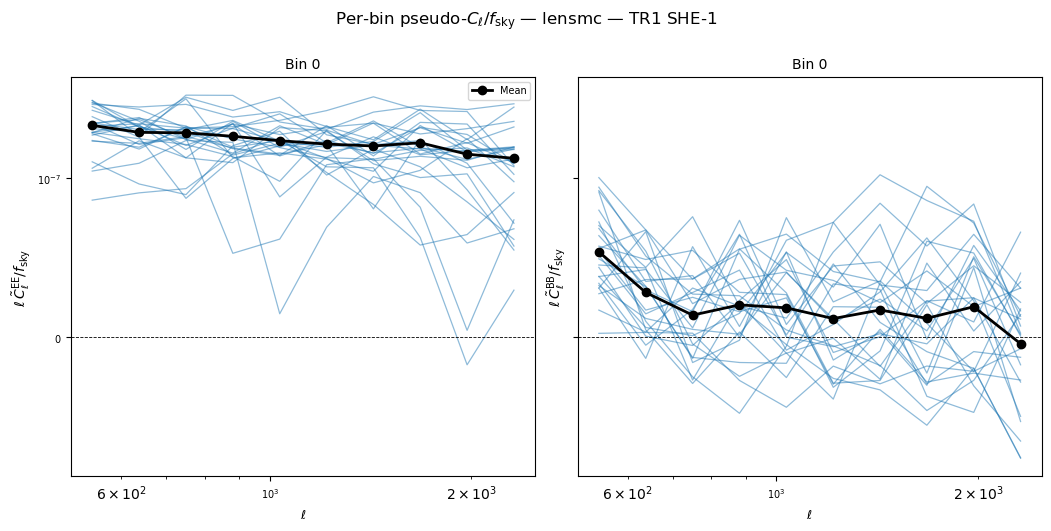

In [82]:
for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        key        = ("SHE", "SHE", ibin, ibin)
        patch_fsky = fsky / n_patches

        # bin each patch's pseudo-Cl with ledges and rescale by fsky
        binned_ee = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][0, 0])
            for label in range(1, n_patches + 1)
        ])
        binned_bb = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][1, 1])
            for label in range(1, n_patches + 1)
        ])
        ell = heracles.binned(all_data_cls[method][1][ibin], ledges)[key].ell

        for row, (label_str, patch_arr) in enumerate([("EE", binned_ee), ("BB", binned_bb)]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(ell, ell * patch_arr[k] / patch_fsky,
                        color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(ell, ell * patch_arr.mean(axis=0) / patch_fsky, 'o-',
                    color="k", lw=2, zorder=5, label="Mean")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,\tilde{C}_\ell^{\rm " + label_str + r"} / f_{\rm sky}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        r"Per-bin pseudo-$C_\ell / f_{\rm sky}$" + f" \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


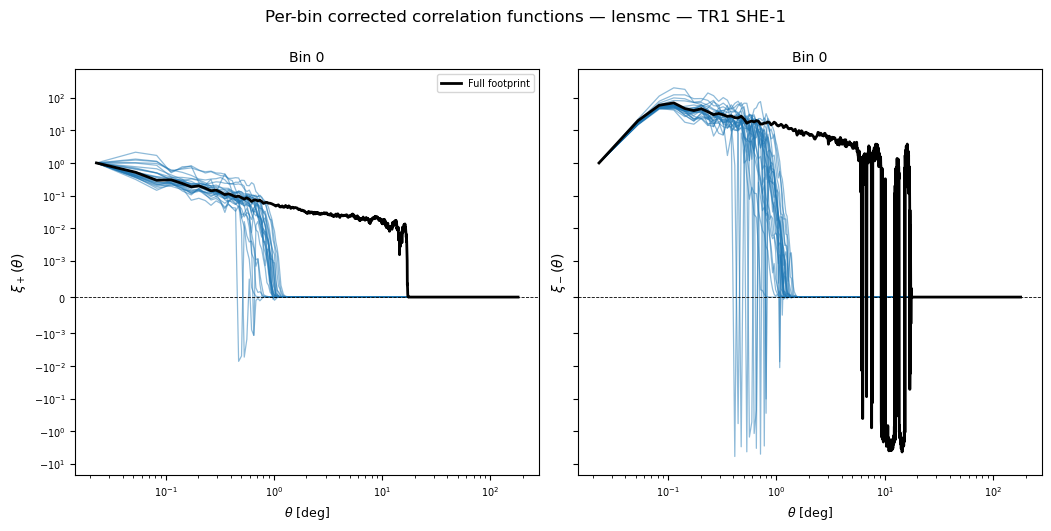

In [83]:
_sort      = np.argsort(theta_full)
theta_plot = theta_full[_sort]

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        full_xip  = np.array(all_corrf_full[method][ibin][0, 0])[_sort]
        full_xim  = np.array(all_corrf_full[method][ibin][1, 1])[_sort]
        patch_xip = np.array([np.array(all_corrf[method][label][ibin][0, 0])[_sort] for label in range(1, n_patches + 1)])
        patch_xim = np.array([np.array(all_corrf[method][label][ibin][1, 1])[_sort] for label in range(1, n_patches + 1)])

        for row, (label_str, full_arr, patch_arr) in enumerate([
            (r"$\xi_+(\theta)$", full_xip, patch_xip),
            (r"$\xi_-(\theta)$", full_xim, patch_xim),
        ]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(theta_plot, patch_arr[k]/patch_arr[k][0], color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(theta_plot, full_arr/full_arr[0], color="k", lw=2, zorder=5, label="Full footprint")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-3)
            ax.set_xlabel(r"$\theta$ [deg]", fontsize=9)
            if col == 0:
                ax.set_ylabel(label_str, fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin corrected correlation functions \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


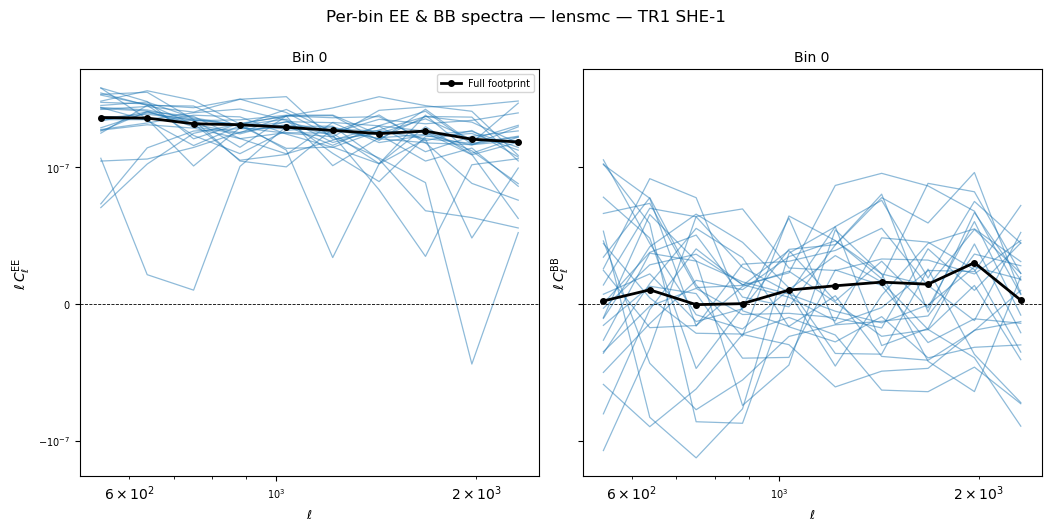

In [84]:
patch_colors = plt.cm.tab20(np.linspace(0, 1, n_patches))

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        cl_data = all_cl_full[method][ibin]

        for row, (component, comp_idx) in enumerate([
            ("EE", (0, 0)),
            ("BB", (1, 1)),
        ]):
            ax = axes[row]

            # Per-region deconvolved Cls
            patches = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            for k in range(patches.shape[0]):
                ax.plot(lgrid, lgrid * patches[k],
                        color='C0', alpha=0.5, lw=0.9, zorder=2)

            # Full-footprint Cl
            ax.plot(lgrid, lgrid * np.array(cl_data[comp_idx]),
                    "o-", ms=4, lw=2, color="k", zorder=5, label="Full footprint")

            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,C_\ell^{\rm " + component + r"}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin EE & BB spectra \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


## 7. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all
**other** patches:
$$\mu_{{-k}} = \frac{{1}}{{N-1}}\sum_{{j\neq k}} C_\ell^{{EE,j}}$$

The leave-one-out (LOO) $\chi^2$ is the Mahalanobis distance using the
covariance estimated from those same $N-1$ patches, so the outlier cannot
inflate its own reference or covariance.  Bins with $\ell < \ell_{{\min}}$
are excluded.

In [118]:
from scipy.stats import chi2 as chi2_dist

print(f"Using {nlbins} ell bins with ell >= {lmin}\n")

# all_chi2_loo[method][ibin], shape (N,)
all_chi2_loo = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_chi2 = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])

        chi2_loo = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest    = [j for j in range(n_patches) if j != k]
            mu_loo      = cls_chi2[idx_rest].mean(axis=0)
            cov_loo     = np.cov(cls_chi2[idx_rest].T)
            diff        = cls_chi2[k] - mu_loo
            chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

        all_chi2_loo[method][ibin] = chi2_loo
        n_out = (chi2_loo / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}: {n_out}/{n_patches} outliers  "
              f"(max reduced chi2 = {chi2_loo.max()/nlbins:.2f})")
    print()


Using 10 ell bins with ell >= 500

  [lensmc] bin 0: 5/25 outliers  (max reduced chi2 = 5.91)



## 8. B-mode null test

We test the null hypothesis $H_0: C_\ell^{BB} = 0$ at two levels:

1. **Full footprint** — is the full-survey BB spectrum consistent with zero?  
   We use the sample covariance of the per-patch BBs divided by $N$ as the
   covariance of the full-footprint estimator, then form
   $\chi^2 = \mathbf{C}_\ell^{BB\,T}\,\mathrm{Cov}^{-1}\,\mathbf{C}_\ell^{BB}$
   and compare to $\chi^2(p)$.

2. **Per patch** — which individual patches show significant non-zero BB?  
   For each patch $k$ we use the leave-one-out covariance of the BB spectra
   from the remaining $N-1$ patches as the noise model and test
   $\mathbf{C}_\ell^{BB,k}$ against zero.

In [119]:
print(f"B-mode null test  (H\u2080: C\u2113\u1d2e\u1d2e = 0,  {nlbins} dof)\n")

# all_chi2_bb_full[method][ibin]  = {"chi2": scalar}
# all_chi2_bb_patch[method][ibin] = array shape (N,)
all_chi2_bb_full  = {method: {} for method in methods}
all_chi2_bb_patch = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_patches_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        # Full-footprint test
        cov_bb_full  = np.cov(cls_patches_bb.T) / n_patches
        cl_bb_full   = np.array(all_cl_full[method][ibin][1, 1])
        chi2_bb_full = cl_bb_full @ np.linalg.inv(cov_bb_full) @ cl_bb_full
        all_chi2_bb_full[method][ibin] = {"chi2": chi2_bb_full}

        # Per-patch: test against zero using LOO cov from BB scatter
        chi2_bb_patch = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest         = [j for j in range(n_patches) if j != k]
            cov_loo_bb       = np.cov(cls_patches_bb[idx_rest].T)
            chi2_bb_patch[k] = cls_patches_bb[k] @ np.linalg.inv(cov_loo_bb) @ cls_patches_bb[k]
        all_chi2_bb_patch[method][ibin] = chi2_bb_patch

        n_out = (chi2_bb_patch / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}:  full \u03c7\u00b2/nlbins = {chi2_bb_full/nlbins:.3f}  |  "
              f"per-patch outliers = {n_out}/{n_patches}")
    print()


B-mode null test  (H₀: Cℓᴮᴮ = 0,  10 dof)

  [lensmc] bin 0:  full χ²/nlbins = 2.499  |  per-patch outliers = 4/25



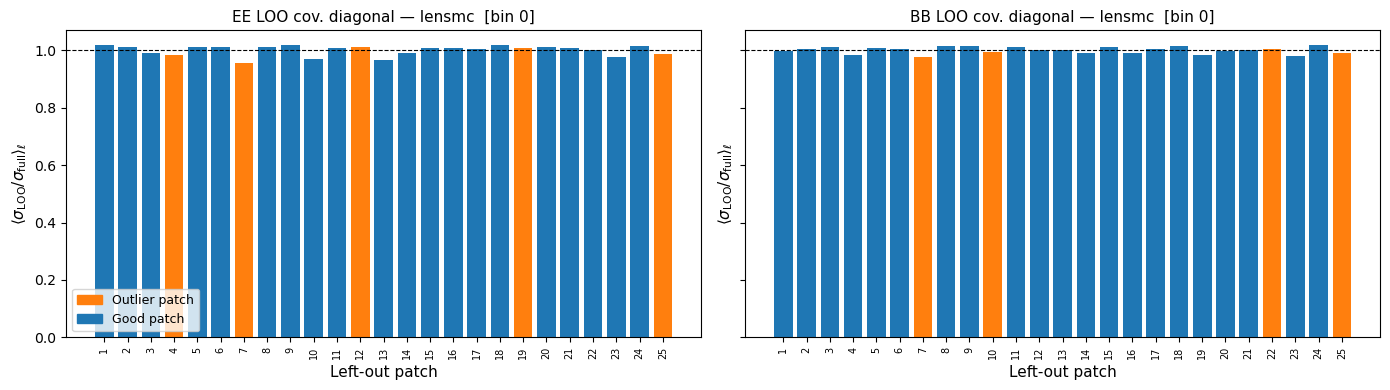

In [120]:
# LOO covariance diagonal diagnostic
# For each left-out patch k, compute the ell-averaged ratio of diag(Cov_{-k}) to diag(Cov_full).
# A ratio far from 1 signals that the covariance is driven by that single region.

for method in methods:
    for ibin in bins:
        cls_ee = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])
        cls_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
        patch_labels = [str(k + 1) for k in range(n_patches)]

        for ax, (label_str, cls, chi2_data) in zip(axes, [
            ("EE", cls_ee, all_chi2_loo[method][ibin]),
            ("BB", cls_bb, all_chi2_bb_patch[method][ibin]),
        ]):
            diag_full = np.sqrt(np.diag(np.cov(cls.T)))

            ratios = np.array([
                np.mean(np.sqrt(np.diag(np.cov(cls[[j for j in range(n_patches) if j != k]].T))) / diag_full)
                for k in range(n_patches)
            ])
            is_out = chi2_data / nlbins > 3
            colors = ["C1" if o else "C0" for o in is_out]

            ax.bar(patch_labels, ratios, color=colors)
            ax.axhline(1, color="k", lw=0.8, ls="--")
            ax.set_xlabel("Left-out patch", fontsize=11)
            ax.set_ylabel(r"$\langle\sigma_{\rm LOO} / \sigma_{\rm full}\rangle_\ell$", fontsize=11)
            ax.set_title(f"{label_str} LOO cov. diagonal \u2014 {method}  [bin {ibin}]", fontsize=11)
            ax.tick_params(axis="x", labelsize=7, rotation=90)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color="C1", label="Outlier patch"),
            plt.Rectangle((0, 0), 1, 1, color="C0", label="Good patch"),
        ]
        axes[0].legend(handles=handles, fontsize=9)
        plt.tight_layout()
        plt.show()


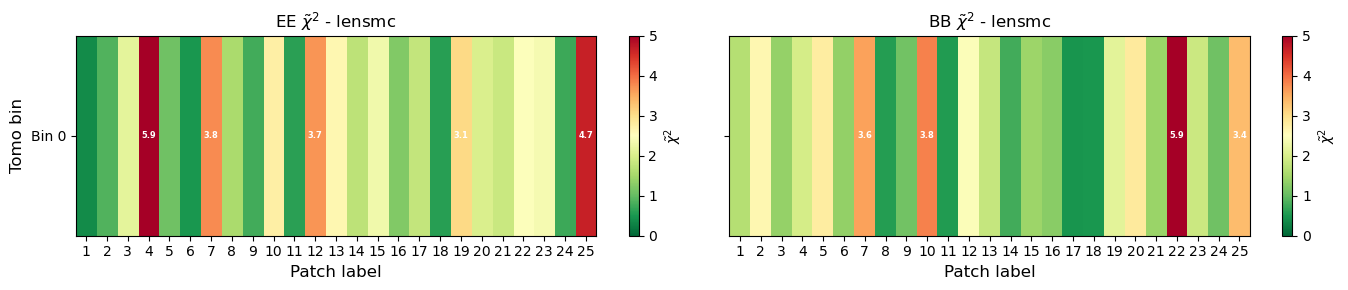

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

for row, method in enumerate(methods):
    for col, (label_str, chi2_data) in enumerate([
        ("EE", all_chi2_loo),
        ("BB", all_chi2_bb_patch),
    ]):
        ax = axes[col]
        mat = np.array([chi2_data[method][ibin] / nlbins for ibin in bins])
        im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=5,
                        extent=[0.5, n_patches + 0.5, len(bins) - 0.5, -0.5])
        ax.set_xlabel("Patch label", fontsize=12)
        if col == 0:
            ax.set_ylabel("Tomo bin", fontsize=12)
        ax.set_xticks(range(1, n_patches + 1))
        ax.set_yticks(range(len(bins)))
        ax.set_yticklabels([f"Bin {i}" for i in bins])
        ax.set_title(rf"{label_str} $\tilde{{\chi}}^2$ - {method}", fontsize=12)
        plt.colorbar(im, ax=ax, label=r"$\tilde{\chi}^2$")
        for bi, ibin in enumerate(bins):
            for k in range(n_patches):
                val = chi2_data[method][ibin][k] / nlbins
                if val > 3:
                    ax.text(k + 1, bi, f"{val:.1f}", ha="center", va="center",
                            fontsize=6, color="white", fontweight="bold")

plt.tight_layout()
plt.show()


/tmp/ipykernel_74424/90271142.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


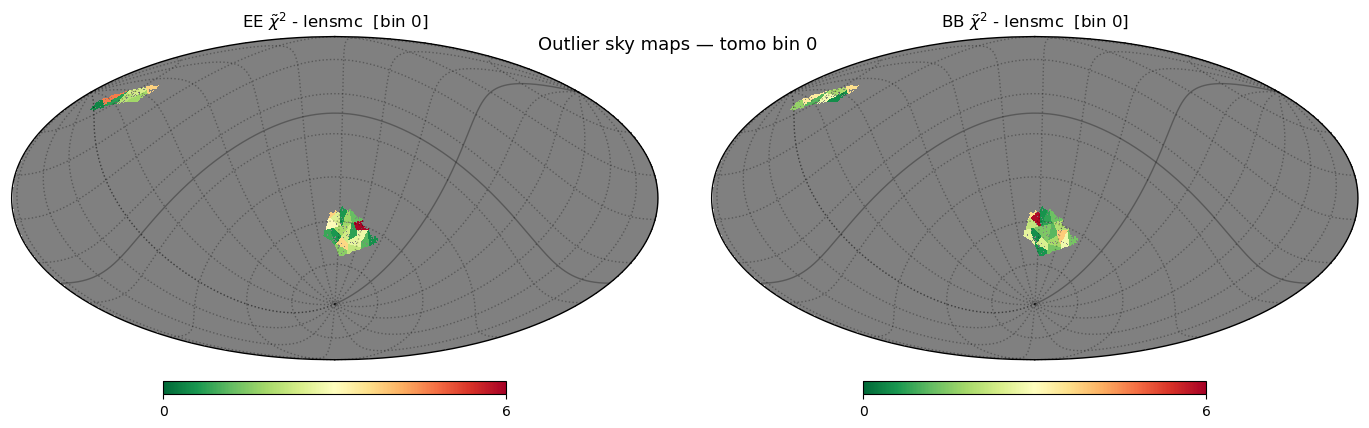

In [126]:
for ibin in bins:
    fig = plt.figure(figsize=(14, 8))
    for row, method in enumerate(methods):
        for col, (label_str, chi2_data) in enumerate([
            ("EE", all_chi2_loo),
            ("BB", all_chi2_bb_patch),
        ]):
            sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
            for k in range(n_patches):
                sky_chi2[jkmap == k + 1] = chi2_data[method][ibin][k] / nlbins
            hp.mollview(
                sky_chi2, fig=fig, sub=(2, 2, row * 2 + col + 1),
                rot=(lon_c, lat_c, 0),
                title=rf"{label_str} $\tilde{{\chi}}^2$ - {method}  [bin {ibin}]",
                cmap="RdYlGn_r", min=0, max=6, notext=True,
            )
    hp.graticule(dpar=5, dmer=5, alpha=0.3)
    plt.suptitle(f"Outlier sky maps \u2014 tomo bin {ibin}", fontsize=13)
    plt.tight_layout()
    plt.show()


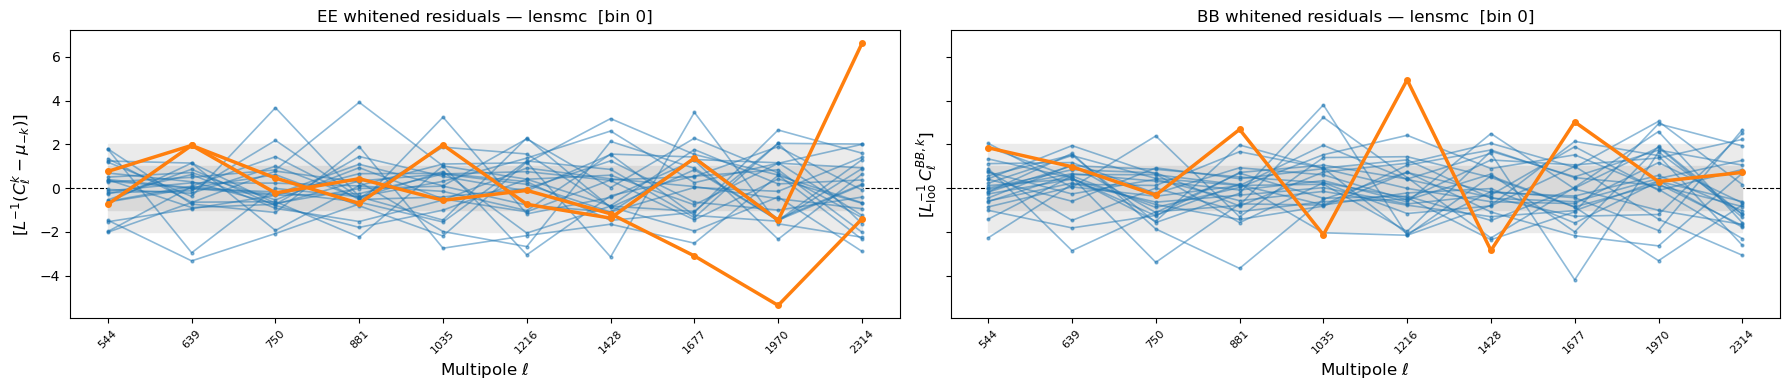

In [ ]:
for ibin in bins:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey="row")

    for row, method in enumerate(methods):
        for col, (label_str, comp_idx, chi2_data, null) in enumerate([
            ("EE", (0, 0), all_chi2_loo,      False),
            ("BB", (1, 1), all_chi2_bb_patch, True),
        ]):
            ax = axes[col]
            cls       = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            chi2_vals = chi2_data[method][ibin]

            ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
            ax.fill_between(range(nlbins), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
            ax.fill_between(range(nlbins), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

            for k in range(n_patches):
                idx_rest = [j for j in range(n_patches) if j != k]
                cov_loo  = np.cov(cls[idx_rest].T)
                L        = np.linalg.cholesky(cov_loo)
                mu       = np.zeros(nlbins) if null else cls[idx_rest].mean(axis=0)
                w        = np.linalg.solve(L, cls[k] - mu)

                is_out = chi2_vals[k] / nlbins > 3
                lbl    = f"Patch {k+1} (outlier)" if is_out else ("Good patches" if k == 0 else None)
                ax.plot(range(nlbins), w, color="C1" if is_out else "C0",
                        lw=2.5 if is_out else 1.2, alpha=1.0 if is_out else 0.5,
                        marker="o", ms=4 if is_out else 2,
                        zorder=5 if is_out else 2, label=lbl)

            ax.set_xticks(range(nlbins))
            ax.set_xticklabels([f"{l:.0f}" for l in lgrid], rotation=45, fontsize=8)
            ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
            ax.set_ylabel(r"$[L^{-1}(C_\ell^k - \mu_{-k})]$" if not null
                          else r"$[L^{-1}_{\rm loo}\,C_\ell^{BB,k}]$", fontsize=12)
            ax.set_title(f"{label_str} whitened residuals \u2014 {method}  [bin {ibin}]", fontsize=12)
            #ax.set_yscale("symlog", linthresh=5E0)
            #ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
